29034 rpm mean, bin = 18.5 rpm


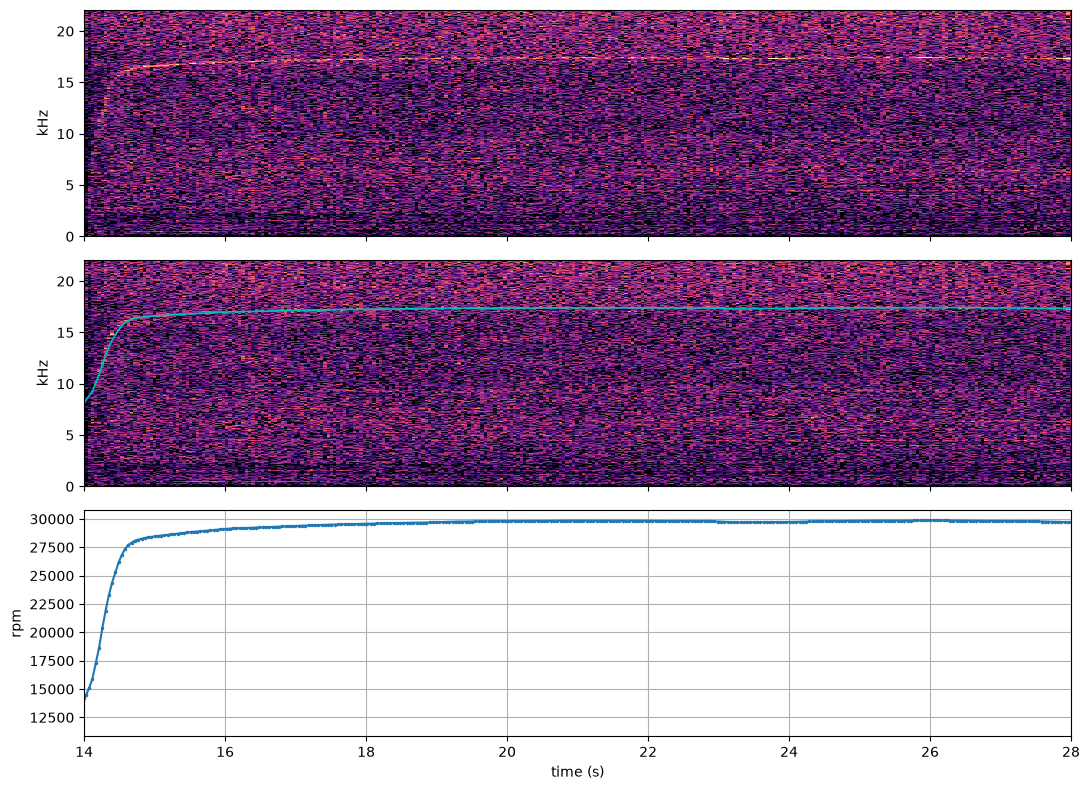

In [11]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt


WAV, BLADES = "20260701-111_Canon_700D.wav", 35
N, H = 4096, 2048          # window, hop
JUMP_HZ, MIN_DB = 400, 8   # max ridge move per frame, tone-lost threshold

# load
fs, x = wavfile.read(WAV)
x = x.astype(float)
if x.ndim > 1: x = x[:, 0]
x /= np.abs(x).max()

# stft
win = np.hanning(N)
nframes = 1 + (len(x) - N)//H
S = np.empty((N//2 + 1, nframes))
for i in range(nframes):
    S[:, i] = np.abs(np.fft.rfft(x[i*H : i*H+N] * win))
f = np.fft.rfftfreq(N, 1/fs)
t = (np.arange(nframes)*H + N/2) / fs

# whiten: dB above each bin's own background
W = 20*np.log10(S + 1e-12)
W -= np.median(W, axis=1, keepdims=True)
# W -= np.median(W, axis=0, keepdims=True)

line = np.where(W.max(axis=0) > 12, f[W.argmax(axis=0)], np.nan)
T0, T1 = 14.0, 28.0                       # read off your plot
line[(t < T0) | (t > T1)] = np.nan

import pandas as pd
line = pd.Series(line).rolling(9, center=True, min_periods=3).median()
line = line.rolling(9, center=True, min_periods=3).mean().to_numpy()

rpm = 60 * line / BLADES

# plot
fig, (a0, a1, a2) = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
a0.pcolormesh(t, f/1000, W, shading="nearest", cmap="magma", vmin=0, vmax=25)
a1.pcolormesh(t, f/1000, W, shading="nearest", cmap="magma", vmin=0, vmax=25)
a1.plot(t, line/1000, "c", lw=1.2)
a1.set_ylabel("kHz")
a0.set_ylabel("kHz")
a2.plot(t, rpm, ".-", ms=3)
a2.set_ylabel("rpm"); a2.set_xlabel("time (s)"); a2.grid()
a1.set_xlim(T0, T1)
plt.tight_layout()

print(f"{np.nanmean(rpm):.0f} rpm mean, bin = {(f[1]-f[0])*60/BLADES:.1f} rpm")

Text(0, 0.5, 'dB above background')

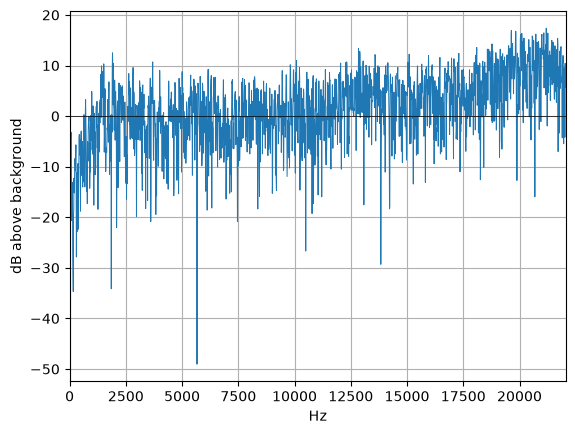

In [8]:
m = np.argmin(np.abs(t - 14.0))
plt.plot(f, W[:, m], lw=0.7); plt.axhline(0, color='k', lw=0.5)
plt.xlim(0, fs/2); plt.grid(); plt.xlabel("Hz"); plt.ylabel("dB above background")

anchor 16624 Hz at t=14.983 s


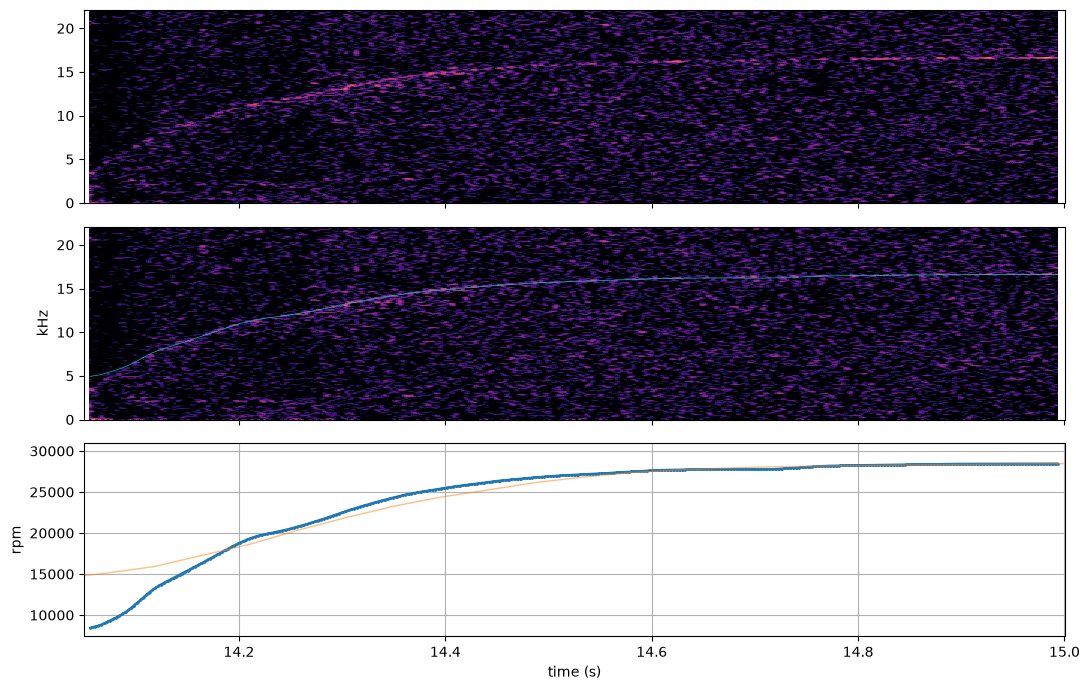

In [9]:
TA, TB = 14.05, 15.0
N2, H2 = 512, 64                  # 11.6 ms window, frame every 1.45 ms
MIN2, JUMP2 = 8, 150

xs = x[int(TA*fs):int(TB*fs)]
win2 = np.hanning(N2)
nf2 = 1 + (len(xs) - N2)//H2
S2 = np.empty((N2//2 + 1, nf2))
for i in range(nf2):
    S2[:, i] = np.abs(np.fft.rfft(xs[i*H2 : i*H2+N2] * win2))
f2 = np.fft.rfftfreq(N2, 1/fs)
t2 = TA + (np.arange(nf2)*H2 + N2/2)/fs

W2 = 20*np.log10(S2 + 1e-12)
W2 -= np.median(W2, axis=1, keepdims=True)

m_lo = np.searchsorted(t2, TB - 0.15)
k0, m0 = np.unravel_index(W2[:, m_lo:].argmax(), W2[:, m_lo:].shape)
m0 += m_lo
print(f"anchor {f2[k0]:.0f} Hz at t={t2[m0]:.3f} s")

j = int(round(JUMP2/(f2[1]-f2[0])))
kidx = np.full(nf2, -1)
kidx[m0] = k0
for d in (1, -1):
    kk, m, gap = k0, m0 + d, 0
    while 0 <= m < nf2:
        w = j*(1 + gap)
        lo, hi = max(0, kk - w), min(len(f2), kk + w + 1)
        b = lo + W2[lo:hi, m].argmax()
        if W2[b, m] >= MIN2:
            kidx[m], kk, gap = b, b, 0
        else:
            gap += 1
            if gap > 30: break
        m += d

# parabolic refine, 148 rpm/bin -> ~10 rpm
line2 = np.full(nf2, np.nan)
v = np.flatnonzero(kidx >= 0)
kk = np.clip(kidx[v], 1, W2.shape[0]-2)
a, b, c = W2[kk-1, v], W2[kk, v], W2[kk+1, v]
den = a - 2*b + c
dd = np.clip(0.5*(a-c)/np.where(den != 0, den, 1), -0.5, 0.5)
line2[v] = f2[kk] + dd*(f2[1]-f2[0])

line2 = pd.Series(line2).rolling(41, center=True, min_periods=2).median()
line2 = pd.Series(line2).rolling(41, center=True, min_periods=2).mean()
line2 = line2.interpolate(limit_area="inside") 
line2 = line2.rolling(15, center=True, min_periods=2).mean().to_numpy()
rpm2 = 60 * line2 / BLADES

fig, (b0, b1, b2) = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
b0.pcolormesh(t2, f2/1000, W2, shading="nearest", cmap="magma", vmin=0, vmax=25)
b1.pcolormesh(t2, f2/1000, W2, shading="nearest", cmap="magma", vmin=0, vmax=25)
b1.plot(t2, line2/1000, "c", lw=0.5); b1.set_ylabel("kHz")
b2.plot(t2, rpm2, ".-", ms=2); b2.set_ylabel("rpm"); b2.set_xlabel("time (s)"); b2.grid()
b2.plot(t, rpm, lw=1, alpha=0.5)          # your N=4096 result for comparison
plt.xlim(TA, TB)
plt.tight_layout()

at 14.6s  coarse 27384  fine 27640 rpm


(14.0, 15.0)

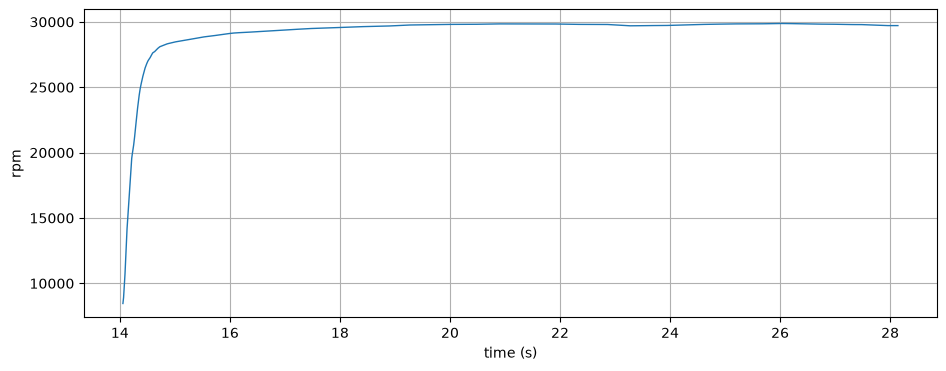

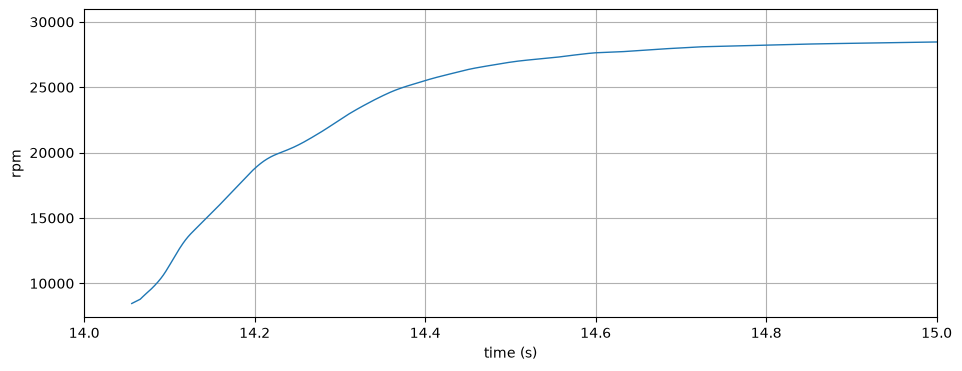

In [10]:
TX = 14.6                      # crossover: fine pass before, coarse after

m2 = np.isfinite(line2) & (t2 <= TX)
m1 = np.isfinite(line)  & (t  >  TX)

t_all   = np.concatenate([t2[m2], t[m1]])
rpm_all = 60 * np.concatenate([line2[m2], line[m1]]) / BLADES

i1, i2 = np.argmin(abs(t - TX)), np.argmin(abs(t2 - TX))
print(f"at {TX}s  coarse {60*line[i1]/BLADES:.0f}  fine {60*line2[i2]/BLADES:.0f} rpm")

t_u = np.arange(t_all[0], t_all[-1], 0.001)
rpm_u = np.interp(t_u, t_all, rpm_all)

plt.figure(figsize=(11,4))
plt.plot(t_u, rpm_u, "-", lw=1)
plt.ylabel("rpm"); plt.xlabel("time (s)"); plt.grid()

plt.figure(figsize=(11,4))
plt.plot(t_u, rpm_u, "-", lw=1)
plt.ylabel("rpm"); plt.xlabel("time (s)"); plt.grid()
plt.xlim(14.0, 15.0)


In [12]:
# save t_u and rpm_u to csv
pd.DataFrame({"time": t_u, "rpm": rpm_u}).to_csv("rpm.csv", index=False)

Text(0.5, 0, 'Time [sec]')

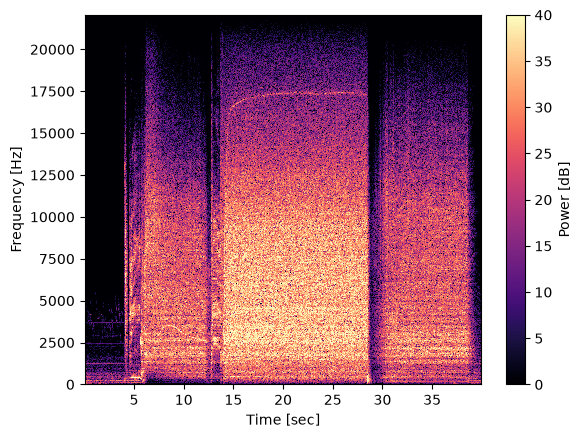

In [19]:
WAV, BLADES = "20260701-111_Canon_700D.wav", 35
N, H = 4096, 2048          # window, hop
JUMP_HZ, MIN_DB = 400, 8   # max ridge move per frame, tone-lost threshold

# load
fs, x = wavfile.read(WAV)
from scipy.signal import spectrogram

f, t, Sxx = spectrogram(x = x, fs = fs, nfft=N, nperseg=N, noverlap=N-H)

plt.pcolormesh(t, f, 10 * np.log10(Sxx), cmap="magma", vmin=0, vmax=40)
plt.colorbar(label="Power [dB]")
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [sec]")
# plt.xlim([0, 2.5])
# plt.ylim(top=5000)


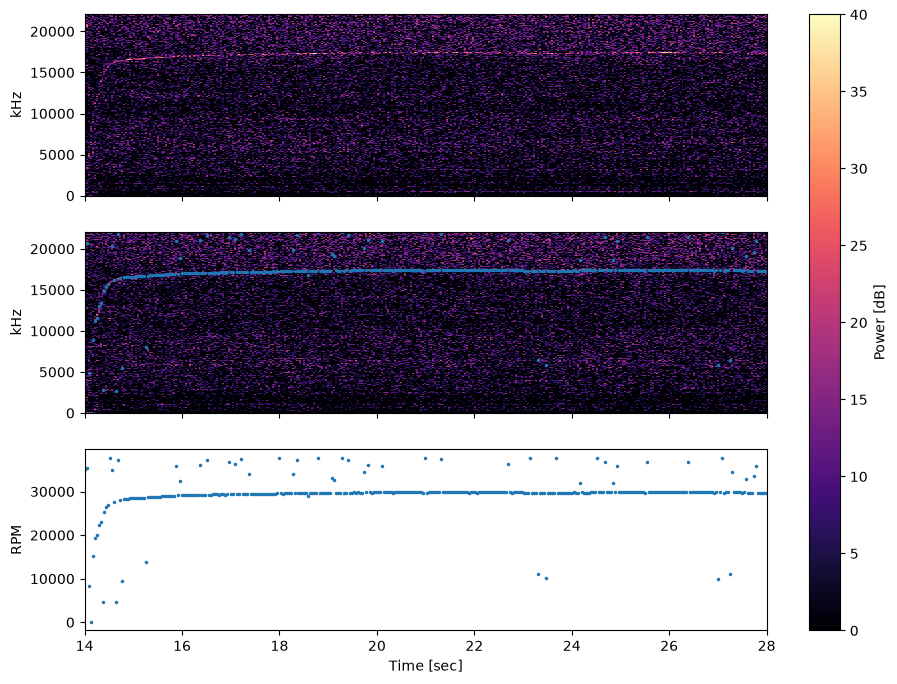

In [28]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from scipy import interpolate



WAV, BLADES = "20260701-111_Canon_700D.wav", 35
fs, x = wavfile.read(WAV)
f, t, Sxx = spectrogram(x = x, fs = fs, nfft=4096, nperseg=2048)

W = 20*np.log10(Sxx + 1e-12)
W -= np.median(W, axis=1, keepdims=True)
W -= np.median(W, axis=0, keepdims=True)

line = np.where(W.max(axis=0) > 12, f[W.argmax(axis=0)], np.nan)
T0, T1 = 14.0, 28.0                       # read off your plot
line[(t < T0) | (t > T1)] = np.nan

import pandas as pd
# line = pd.Series(line).rolling(9, center=True, min_periods=3).median()
# line = line.rolling(9, center=True, min_periods=3).mean().to_numpy()

FPS = 60
rpm = FPS * line / BLADES



fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

pcm = ax0.pcolormesh(t, f, W, cmap="magma",vmin=0, vmax=40)
ax0.set_ylabel("kHz")

ax1.pcolormesh(t, f, W, cmap="magma",vmin=0, vmax=40)
ax1.plot(t, line, ".", ms=3)
ax1.set_ylabel("kHz")

ax2.plot(t, rpm, ".", ms=3)
ax2.set_ylabel("RPM")

ax2.set_xlabel("Time [sec]")
ax2.set_xlim([14, 28])
fig.colorbar(pcm, ax=[ax0, ax1, ax2], label="Power [dB]")

# import pandas as pd
# pd.DataFrame({"time": t_array, "rpm": func(t_array)}).to_csv("rpm.csv", index=False)

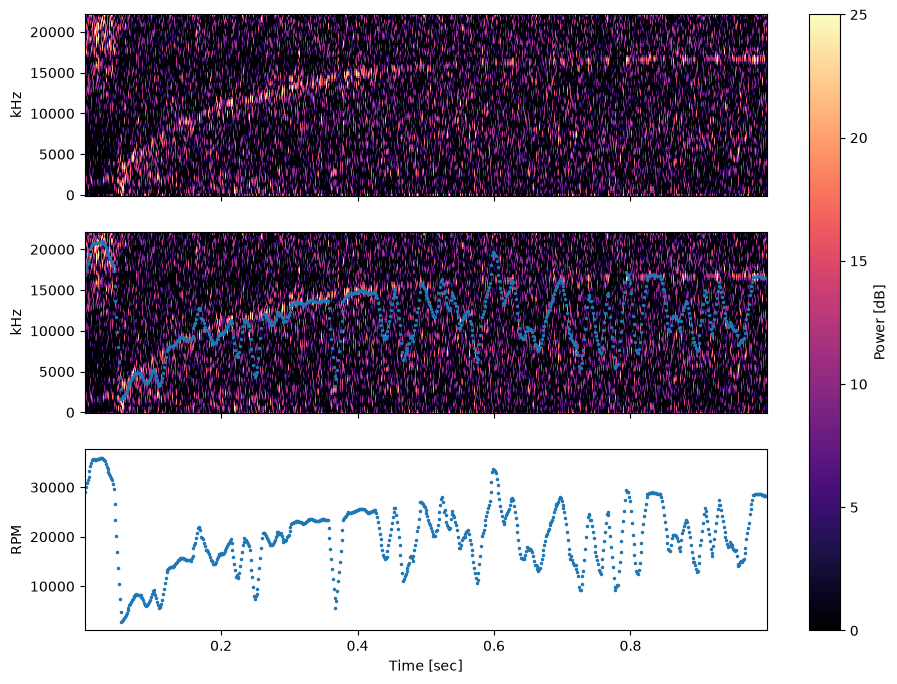

In [ ]:
WAV, BLADES = "20260701-111_Canon_700D.wav", 35
fs, x = wavfile.read(WAV)
f, t, Sxx = spectrogram(x = x[int(14*fs):int(15*fs)], fs = fs, nfft=512, nperseg=64)

W = 20*np.log10(Sxx + 1e-12)
W -= np.median(W, axis=1, keepdims=True)
W -= np.median(W, axis=0, keepdims=True)

samples = 1 + (len(x) - 512)//64

line2 = np.full(nf2, np.nan)
v = np.flatnonzero(kidx >= 0)
kk = np.clip(kidx[v], 1, W2.shape[0]-2)
a, b, c = W2[kk-1, v], W2[kk, v], W2[kk+1, v]
den = a - 2*b + c
dd = np.clip(0.5*(a-c)/np.where(den != 0, den, 1), -0.5, 0.5)
line2[v] = f2[kk] + dd*(f2[1]-f2[0])

# line = np.where(W.max(axis=0) > 12, f[W.argmax(axis=0)], np.nan)
# T0, T1 = 0, 1                       # read off your plot
# line[(t < T0) | (t > T1)] = np.nan

# import pandas as pd
# line = pd.Series(line).rolling(9, center=True, min_periods=3).median()
# line = line.rolling(9, center=True, min_periods=3).mean().to_numpy()



FPS = 60
rpm = FPS * line / BLADES



fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

pcm = ax0.pcolormesh(t, f, W, cmap="magma",vmin=0, vmax=25)
ax0.set_ylabel("kHz")

ax1.pcolormesh(t, f, W, cmap="magma",vmin=0, vmax=25)
ax1.plot(t, line, ".", ms=3)
ax1.set_ylabel("kHz")

ax2.plot(t, rpm, ".", ms=3)
ax2.set_ylabel("RPM")

ax2.set_xlabel("Time [sec]")
# ax2.set_xlim([14, 28])
fig.colorbar(pcm, ax=[ax0, ax1, ax2], label="Power [dB]")
